# Exploración Inicial de Datos (EDA) - Predicción de Insuficiencia Cardíaca
**Autor:** Isabel
**Algoritmo asignado para el modelo final:** K-Nearest Neighbors (K-NN)

## 📝 Descripción
En este notebook realizaremos el análisis exploratorio de datos (EDA) para entender las variables del dataset `heart.csv`. 
[cite_start]El objetivo es responder a las preguntas de investigación planteadas por el equipo.

--- Balance de Clases ---
HeartDisease
1    508
0    410
Name: count, dtype: int64

--- Porcentaje ---
HeartDisease
1    55.337691
0    44.662309
Name: proportion, dtype: float64


C:\Users\Coder\AppData\Local\Temp\ipykernel_39344\269236901.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='HeartDisease', data=df_eda, palette='viridis')


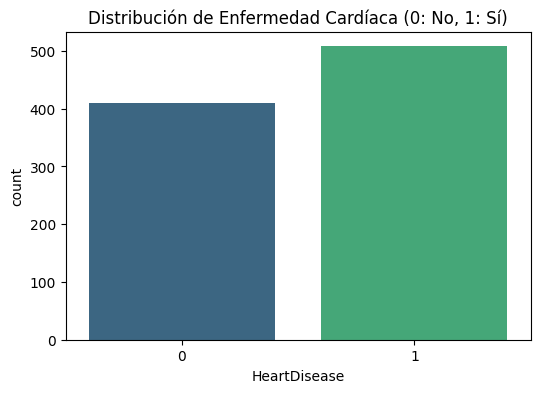

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Carga de datos
# Usamos ruta relativa para no modificar el original en /data
df = pd.read_csv('../data/heart.csv')
df_eda = df.copy()

# 2. Exploración General - Balance de clases
# Respondemos: ¿Cuántos pacientes hay con y sin enfermedad cardíaca?
print("--- Balance de Clases ---")
print(df_eda['HeartDisease'].value_counts())
print("\n--- Porcentaje ---")
print(df_eda['HeartDisease'].value_counts(normalize=True) * 100)

# 3. Visualización
plt.figure(figsize=(6,4))
sns.countplot(x='HeartDisease', data=df_eda, palette='viridis')
plt.title('Distribución de Enfermedad Cardíaca (0: No, 1: Sí)')
plt.show()

# Mostramos las primeras filas para confirmar que todo está correcto
df_eda.head()

--- Estadísticas de Edad ---
count    918.000000
mean      53.510893
std        9.432617
min       28.000000
25%       47.000000
50%       54.000000
75%       60.000000
max       77.000000
Name: Age, dtype: float64


C:\Users\Coder\AppData\Local\Temp\ipykernel_39344\1111140300.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Sex', data=df_eda, palette='magma')


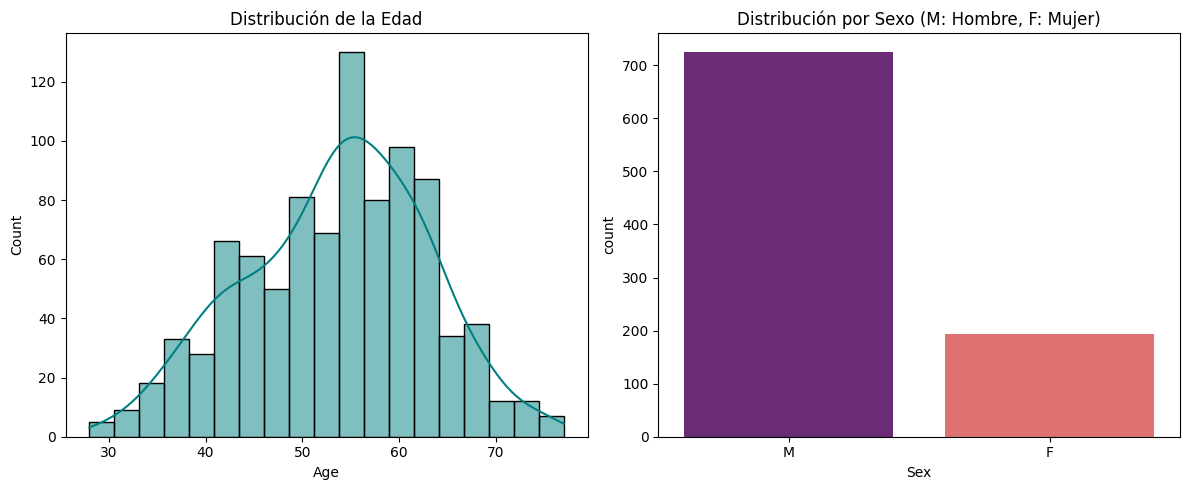

In [3]:
# 3.1 Características demográficas
# Analizamos la distribución de Edad y Sexo de los pacientes

print("--- Estadísticas de Edad ---")
print(df_eda['Age'].describe())

# Visualizamos la distribución de edad y el sexo
plt.figure(figsize=(12, 5))

# Histograma de edad
plt.subplot(1, 2, 1)
sns.histplot(df_eda['Age'], kde=True, color='teal')
plt.title('Distribución de la Edad')

# Gráfico de barras por Sexo
plt.subplot(1, 2, 2)
sns.countplot(x='Sex', data=df_eda, palette='magma')
plt.title('Distribución por Sexo (M: Hombre, F: Mujer)')

plt.tight_layout()
plt.show()

In [4]:
# 3.1 Datos faltantes e inconsistencias
# Comprobamos si hay huecos en la información

print("--- Datos faltantes por columna ---")
print(df_eda.isnull().sum())

print("\n--- Tipos de datos ---")
print(df_eda.dtypes)

# Resumen estadístico para ver si hay valores imposibles (ej. Colesterol = 0)
df_eda.describe()

--- Datos faltantes por columna ---
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

--- Tipos de datos ---
Age                 int64
Sex                   str
ChestPainType         str
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG            str
MaxHR               int64
ExerciseAngina        str
Oldpeak           float64
ST_Slope              str
HeartDisease        int64
dtype: object


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


Pacientes con RestingBP igual a 0: 1
Pacientes con Cholesterol igual a 0: 172


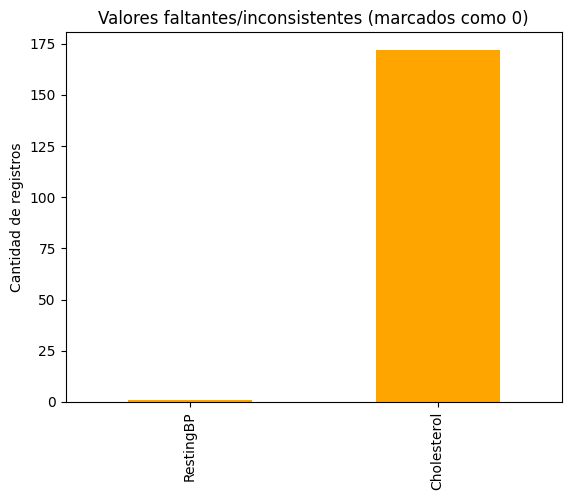

In [5]:
# 3.1 Visualización de inconsistencias
# Vamos a ver cuántos pacientes tienen valores de 0 en Colesterol y Presión

cols_con_ceros = ['RestingBP', 'Cholesterol']
for col in cols_con_ceros:
    cantidad_ceros = (df_eda[col] == 0).sum()
    print(f"Pacientes con {col} igual a 0: {cantidad_ceros}")

# Creamos un gráfico sencillo para el informe
df_eda[cols_con_ceros].replace(0, pd.NA).isnull().sum().plot(kind='bar', color='orange')
plt.title('Valores faltantes/inconsistentes (marcados como 0)')
plt.ylabel('Cantidad de registros')
plt.show()

## 4. Procesamiento de Datos

In [9]:
# 4.1 Tratamiento avanzado de ceros (Imputación por grupos)

# Calculamos las medianas para cada grupo (Sanos vs Enfermos)
# Solo usamos los que tienen colesterol > 0 para que la mediana sea real
medianas_por_grupo = df_eda[df_eda['Cholesterol'] != 0].groupby('HeartDisease')['Cholesterol'].median()

print("Medianas calculadas:")
print(f"Sanos (0): {medianas_por_grupo[0]}")
print(f"Enfermos (1): {medianas_por_grupo[1]}")

# Aplicamos la magia: si el colesterol es 0, le pone la mediana de su grupo
df_eda['Cholesterol'] = df_eda.apply(
    lambda x: medianas_por_grupo[x['HeartDisease']] if x['Cholesterol'] == 0 else x['Cholesterol'], 
    axis=1
)

# El de RestingBP lo arreglamos con la mediana general porque solo era 1 dato
df_eda['RestingBP'] = df_eda['RestingBP'].replace(0, df_eda[df_eda['RestingBP'] != 0]['RestingBP'].median())

# Comprobación final
print(f"\nCeros restantes en Cholesterol: {(df_eda['Cholesterol'] == 0).sum()}")
print(f"Ceros en RestingBP: {(df_eda['RestingBP'] == 0).sum()}")

Medianas calculadas:
Sanos (0): 0.2895752895752896
Enfermos (1): 0.29343629343629346

Ceros restantes en Cholesterol: 0
Ceros en RestingBP: 0


In [8]:
# 4.2 Escalado de variables numéricas (Min-Max Scaling)
from sklearn.preprocessing import MinMaxScaler

# Creamos el objeto escalador
scaler = MinMaxScaler()

# Seleccionamos las columnas numéricas que queremos que pesen lo mismo
cols_a_escalar = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

# Aplicamos el escalado
df_eda[cols_a_escalar] = scaler.fit_transform(df_eda[cols_a_escalar])

# Comprobamos que ahora el máximo de todo es 1 y el mínimo es 0
df_eda[cols_a_escalar].describe().loc[['min', 'max']]

,Age,RestingBP,Cholesterol,MaxHR,Oldpeak
min,0.0,0.0,0.0,0.0,0.0
max,1.0,1.0,1.0,1.0,1.0


In [10]:
# 4.3 Codificación de variables (Letras a Números)

# Para Sex: M -> 1, F -> 0
df_eda['Sex'] = df_eda['Sex'].map({'M': 1, 'F': 0})

# Para ExerciseAngina: Y -> 1, N -> 0
df_eda['ExerciseAngina'] = df_eda['ExerciseAngina'].map({'Y': 1, 'N': 0})

# Comprobamos cómo han quedado los primeros datos
df_eda[['Sex', 'ExerciseAngina']].head()

,Sex,ExerciseAngina
0,1,0
1,0,0
2,1,0
3,0,1
4,1,0


In [11]:
# 4.4 One-Hot Encoding para el resto de variables categóricas

# Usamos la función get_dummies para crear las columnas nuevas
df_final = pd.get_dummies(df_eda, columns=['ChestPainType', 'RestingECG', 'ST_Slope'])

# Mostramos cómo ha quedado el dataset (ahora tendrá más columnas)
print(f"Número de columnas original: {df_eda.shape[1]}")
print(f"Número de columnas final: {df_final.shape[1]}")
df_final.head()

Número de columnas original: 12
Número de columnas final: 19


,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,0.244898,1,0.500000,0.393822,0,0.788732,0,0.295455,0,False,True,False,False,False,True,False,False,False,True
1,0.428571,0,0.666667,0.183398,0,0.676056,0,0.409091,1,False,False,True,False,False,True,False,False,True,False
2,0.183673,1,0.416667,0.382239,0,0.267606,0,0.295455,0,False,True,False,False,False,False,True,False,False,True
3,0.408163,0,0.483333,0.249035,0,0.338028,1,0.465909,1,True,False,False,False,False,True,False,False,True,False
4,0.530612,1,0.583333,0.212355,0,0.436620,0,0.295455,0,False,False,True,False,False,True,False,False,False,True
